**EX 1 - Hailstone shield design (linear elasticity)**

In [ ]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*
import numpy as np
import matplotlib.pyplot as plt
clc()

# FOM solver implementation

In [ ]:
mesh = fe.unitsquaremesh(40, 40) # rescaling from [0cm,6cm]x[0cm,6cm] to [0,1]x[0,1]
Vh = fe.space(mesh, 'CG', 1, vector_valued = True)
Dh = fe.space(mesh, 'DG', 0)
clc()

def FOMsolver(mu):
  r, m, theta = mu                      # theta here is calculated from the x-axis
  x0, delta = 0.5, 0.1                  # x0: center of the horizontal span, delta: hailstone of diameter 1.2cm becomes of radius 0.1 in the rescaled metric

  from ufl_legacy import nabla_div
  from scipy.sparse.linalg import spsolve
  from scipy.sparse import csr_matrix
  from fenics import Constant, DirichletBC, nabla_grad, Identity, TrialFunction, TestFunction, dot, dx, ds, inner, assemble

  # Boundary conditions
  tol = 1e-5
  def clamped_boundary(x, on_boundary):
      return on_boundary and x[1]<tol                               # true if on_boundary = True and z = 0
  bc = DirichletBC(Vh, Constant((0, 0)), clamped_boundary)          # if true I enforce null displacement in both x and z directions "Constant((0, 0))"

  # Auxiliary definitions
  lambda_ = fe.interpolate(lambda x: r*(x[1]>0.5)*1.0 + 1.0*(x[1]<=0.5), Dh)   # lambda: first Lamè coefficient
  nu = fe.interpolate(lambda x: (x[1]>0.5)*r + 1.0*(x[1]<=0.5), Dh)            # nu: second Lamè coefficient

  def epsilon(u):
      return 0.5*(nabla_grad(u) + nabla_grad(u).T)

  def sigma(u):
      return lambda_*nabla_div(u)*Identity(2) + 2*nu*epsilon(u)

  # Variational problem
  u = TrialFunction(Vh)
  v = TestFunction(Vh)
  f = Constant((0, -1))
  T = fe.interpolate(lambda x: [m*np.cos(theta-np.pi/2)*(x[1] > 0.99)*(np.abs(x[0]-x0)<(delta+tol)),
                                   m*np.sin(theta-np.pi/2)*(x[1] > 0.99)*(np.abs(x[0]-x0)<(delta+tol))], Vh)

  a = inner(sigma(u), epsilon(v))*dx
  L = dot(f, v)*dx + dot(T, v)*ds

  # Assembling and adjusting
  A = assemble(a)
  F = assemble(L)
  bc.apply(A)
  bc.apply(F)

  A = csr_matrix(A.array())
  F = F[:]

  # Solving
  u = spsolve(A, F)
  clc()
  return u

Example of a FOM solution

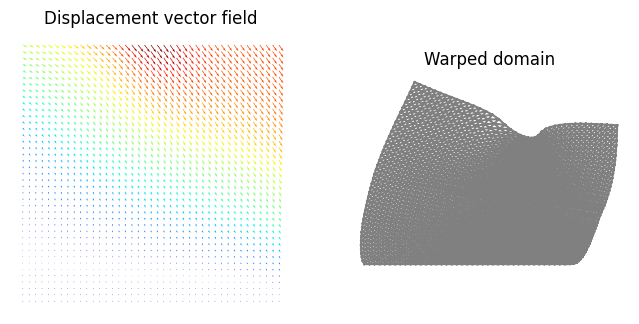

In [ ]:
u = FOMsolver([0.75, 1, 0.4]) # computation of the FOM solution

plt.figure(figsize = (8, 4))
plt.subplot(1, 2, 1)
fe.plot(u, Vh)
plt.title("Displacement vector field")
plt.subplot(1, 2, 2)
fe.plot(u, Vh, warp = True)
plt.title("Warped domain")
None

# Sample 100 snapshots


1.   First batch: 50 latin hypercube samples
2.   Second batch: 50 uniform samples

In [ ]:
from scipy.stats import qmc

bounds = np.array([[0.5, 1.0],      # r: [0.5, 1]
                   [0.5, 2.0],      # m: [0.5, 2]
                   [-0.4, 0.4]])    # theta: [-0.4, 0.4]

# Number of samples
nsim = 100
n_lhs = nsim // 2 # first 50 samples using latin hypercube
n_uniform = nsim - n_lhs # next 50 samples using uniform random

# Latin hypercube samples
sampler = qmc.LatinHypercube(d = 3)  # d = 3 for 3 parameters
lhs_samples_normalized = sampler.random(n = n_lhs)  # samples in [0, 1]^3
lhs_samples = qmc.scale(lhs_samples_normalized, bounds[:, 0], bounds[:, 1]) # scaling LHS samples to actual parameter ranges

# Uniform random samples
uniform_samples = np.random.uniform(low = bounds[:, 0], high = bounds[:, 1], size = (n_uniform, 3))

# Combine both sets
mu = np.vstack([lhs_samples, uniform_samples])

# Check the dimensions of mu
print(f"Total samples: {mu.shape[0]}")
print(f"Number of parameters: {mu.shape[1]}")

# Print some relevant results
print(f"First 5 LHS samples:")
print(mu[:5])
print(f"\nLast 5 uniform samples:")
print(mu[-5:])

Total samples: 100
Number of parameters: 3
First 5 LHS samples:
[[ 0.69920641  1.00599403  0.28537885]
 [ 0.65771138  0.52607246  0.15584759]
 [ 0.72709887  1.35977113  0.38661074]
 [ 0.70745791  1.40395221  0.19859257]
 [ 0.64939624  1.68394283 -0.0133943 ]]

Last 5 uniform samples:
[[ 0.85160482  1.84473692 -0.28632475]
 [ 0.87669303  0.90507843  0.05576838]
 [ 0.96997035  0.66290355 -0.24174465]
 [ 0.66912599  1.64288425 -0.08410125]
 [ 0.81418923  1.2696802  -0.07923436]]


Solve the FOM for the newly generated parameters

In [ ]:
# Solve FOM for mu
from time import perf_counter

t0_FOM = perf_counter()

ulist = []
for i in range(nsim):
  u_i = FOMsolver(mu[i, :])
  ulist.append(u_i)

u = np.stack(ulist)

t1_FOM = perf_counter()

# Check the dimensions of u
print(f"Total samples: {u.shape[0]}")
print(f"DOFs per simulation (Nh): {u.shape[1]}")

Total samples: 100
DOFs per simulation (Nh): 3362


r = 0.6992064099017489, m = 1.0059940297864112 and theta = 0.2853788490211149
r = 0.6577113835073063, m = 0.5260724607113462 and theta = 0.1558475868478426
r = 0.7270988747713697, m = 1.3597711271654669 and theta = 0.3866107405370919


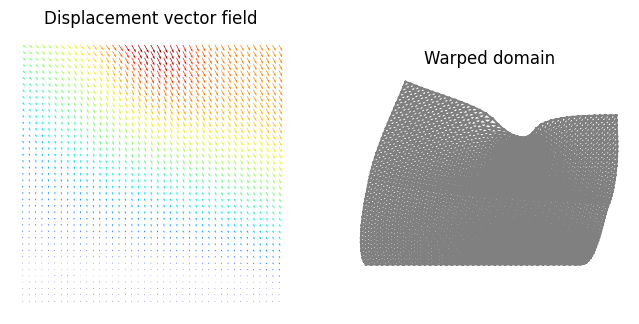

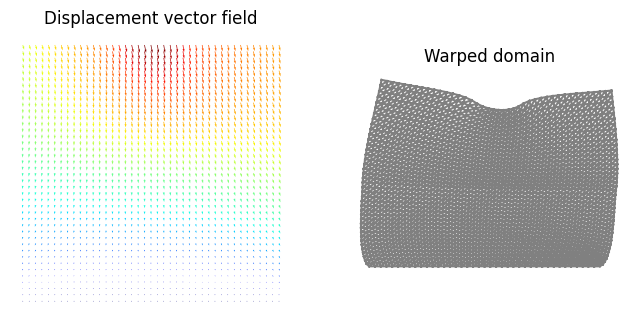

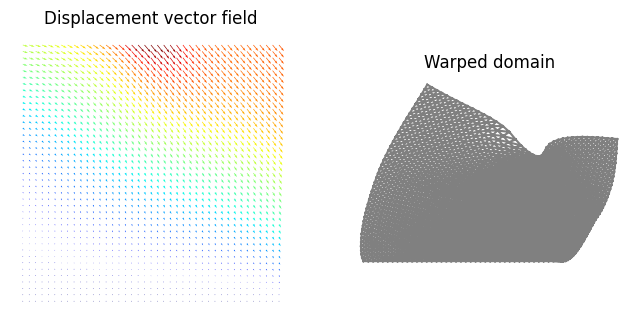

In [ ]:
# Plot the first 3 solutions as an example
for i in range(3):
  print(f'r = {mu[i, 0]}, m = {mu[i, 1]} and theta = {mu[i, 2]}')
  plt.figure(figsize = (8, 4))
  plt.subplot(1, 2, 1)
  fe.plot(u[i], Vh)
  plt.title("Displacement vector field")

  plt.subplot(1, 2, 2)
  fe.plot(u[i], Vh, warp = True)
  plt.title("Warped domain")
  None

# Proper orthogonal decomposition

In [ ]:
# Divide simulation set in 2 subsets: one for training and one for validation
Nh = u.shape[1]
U = u.T # in order to have a matrix (Nh x nsim)
Utrain = u[:n_lhs].T
Utest = u[n_lhs:].T

print(f'Utrain has shape: {Utrain.shape}')
print(f'Utest has shape: {Utest.shape}')

Utrain has shape: (3362, 50)
Utest has shape: (3362, 50)


The rapid decay of the singular values means that POD-Galerkin is the right choice.


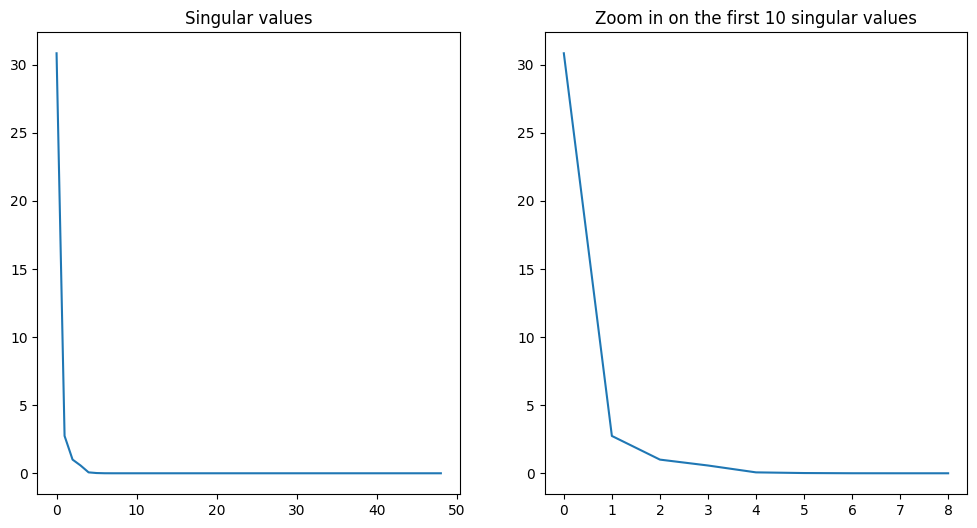

In [ ]:
from scipy.linalg import svd
X, s, Yt = svd(Utrain, full_matrices = False) # singular value decomposition

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.plot(s[1:]) # it's a good habit to neglect the first singular value (very high) and plot from the second one
plt.title('Singular values')

plt.subplot(1, 2, 2)
plt.plot(s[1:10]) # zoom on the first 10 singular values to understand better how many basis functions should be picked out
plt.title('Zoom in on the first 10 singular values')

print(f'The rapid decay of the singular values means that POD-Galerkin is the right choice.')

The final choice is to use 6 basis functions.
V has shape: (3362, 6)


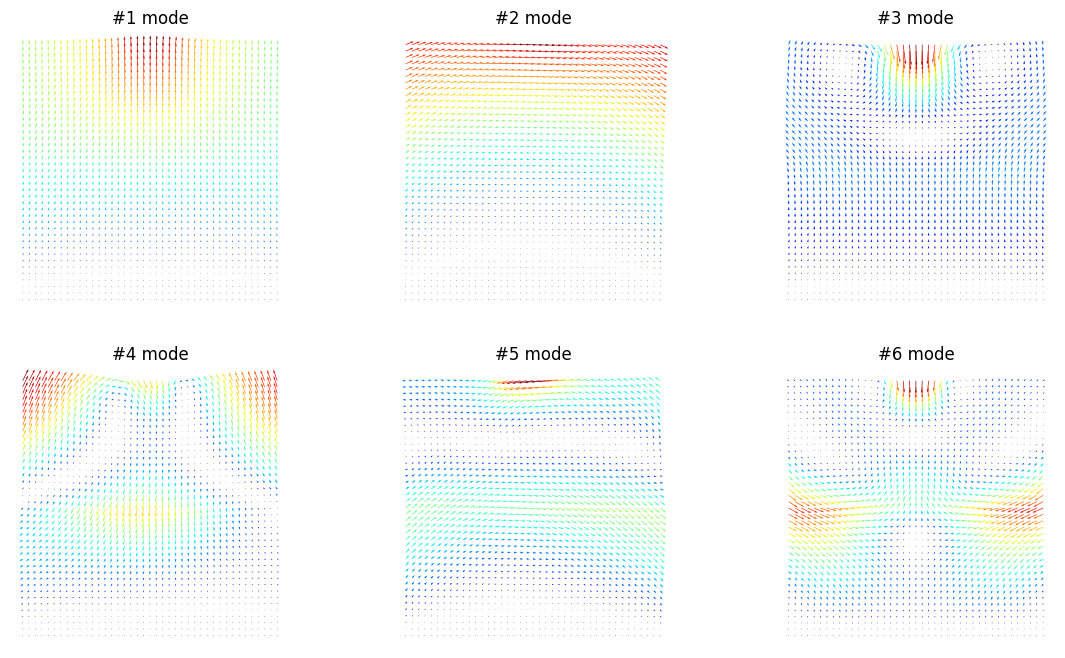

In [ ]:
print(f'The final choice is to use 6 basis functions.')

n = 6; # 6 basis functions
V = X[:, :n]
print(f'V has shape: {V.shape}')

# Plot of the 6 modes
plt.figure(figsize = (14, 8))
for i in range(n):
  plt.subplot(2, n//2, i + 1)
  fe.plot(V[:, i], Vh)
  plt.title("#%d mode" % (i + 1))
plt.show()

In [ ]:
# Compute the projection error
from dlroms import num2p

Uproj = V @ (V.T @ Utrain)
err = (np.linalg.norm(Utrain - Uproj, axis = 0) / np.linalg.norm(Utrain, axis = 0)).mean()
print(f'Average projection error: {num2p(err)}')

Average projection error: 0.02%


# Offline stage: assembling the ROM

In [ ]:
from fenics import *
from ufl_legacy import nabla_div
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix
from fenics import Constant, DirichletBC, nabla_grad, Identity, TrialFunction, TestFunction, dot, dx, ds, inner, assemble

tol = 1e-5

def clamped_boundary(x, on_boundary):
    return on_boundary and x[1] < tol

bc = DirichletBC(Vh, Constant((0,0)), clamped_boundary)

w = TrialFunction(Vh)
v = TestFunction(Vh)

def epsilon(u):
    return 0.5*(nabla_grad(u) + nabla_grad(u).T)

In [ ]:
# A0: affinine parametrization of the bottom layer
lambda0 = Constant(1.0)
nu0 = Constant(1.0)

sigma0 = lambda0*nabla_div(w)*Identity(2) + 2*nu0*epsilon(w)

a0 = inner(sigma0, epsilon(v))*dx

A0 = assemble(a0)
bc.apply(A0)

A0 = csr_matrix(A0.array())

clc()

In [ ]:
# A1: affine parametrization of the upper layer
chi = fe.interpolate(lambda x: 1.0*(x[1] > 0.5), Dh)

sigma1 = chi*nabla_div(w)*Identity(2) + 2*chi*epsilon(w)

a1 = inner(sigma1, epsilon(v))*dx

A1 = assemble(a1)
bc.apply(A1)

A1 = csr_matrix(A1.array())

clc()

In [ ]:
# Fg: affine parametrization of the weight force
f = Constant((0,-1))

Lg = dot(f,v)*dx

Fg = assemble(Lg)

bc.apply(Fg)

Fg = Fg[:]

clc()

In [ ]:
# Fx: affine parametrization of the horizontal component of the impact force
x0 = 0.5
delta = 0.1

Tx = fe.interpolate(lambda x: [1.0*(x[1] > 0.99)*(abs(x[0] - x0) < delta + tol), 0.0], Vh)

Lx = dot(Tx,v)*ds

Fx = assemble(Lx)

bc.apply(Fx)

Fx = Fx[:]

clc()

In [ ]:
# Fz: affine parametrization of the vertical component of the impact force
Tz = fe.interpolate(lambda x: [0.0, 1.0*(x[1] > 0.99)*(abs(x[0] - x0) < delta + tol)], Vh)

Lz = dot(Tz,v)*ds

Fz = assemble(Lz)

bc.apply(Fz)

Fz = Fz[:]

clc()

In [ ]:
# ROM assembly
t0_off = perf_counter()

A0_rb = V.T @ A0 @ V
A1_rb = V.T @ A1 @ V

Fg_rb = V.T @ Fg
Fx_rb = V.T @ Fx
Fz_rb = V.T @ Fz

t1_off = perf_counter()

# Online stage: computation of the solutions

In [ ]:
# Function that computes the solution using the ROM
def RBsolver_affine(mu):

    r, m, theta = mu

    Arb = A0_rb + (r-1)*A1_rb

    frb = (Fg_rb + m*np.sin(theta)*Fx_rb - m*np.cos(theta)*Fz_rb)

    c = np.linalg.solve(Arb, frb)

    return V @ c

In [ ]:
# Computing the ROM solutions
t0_ROM = perf_counter()

urb_list = []

for mu_i in mu:

    urb_i = RBsolver_affine(mu_i)

    urb_list.append(urb_i)

urb = np.stack(urb_list)

t1_ROM = perf_counter()

In [ ]:
# Transposition in order to have a matrix (Nh x nsim)
Urb = urb.T
Urb_train = urb[:n_lhs].T
Urb_test = urb[n_lhs:].T

Comparison between the solution of RB solver and FOM solver for the first sampled parameter:
r =  0.6992064099017489, m = 1.0059940297864112 and theta = 0.2853788490211149


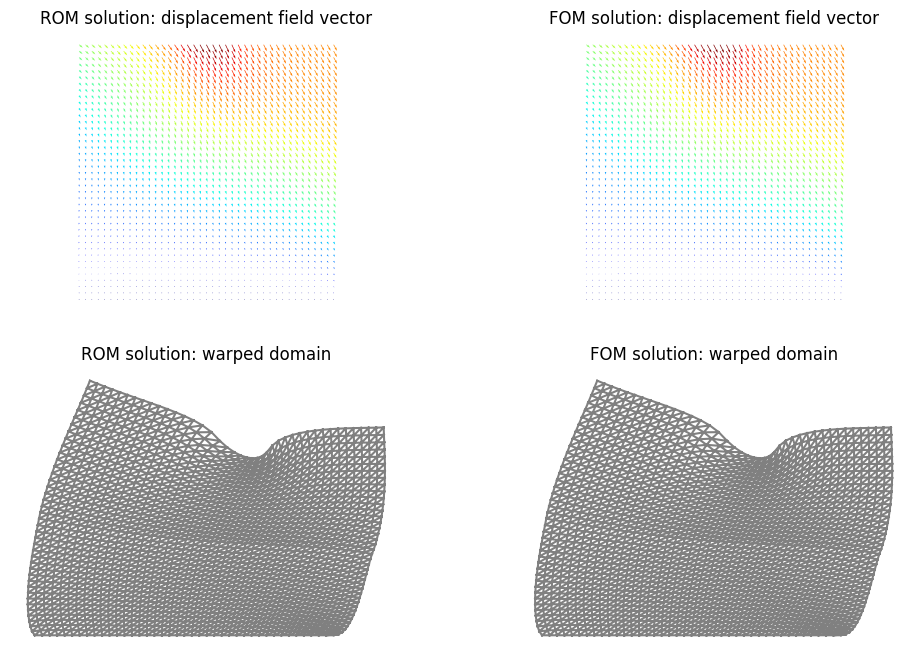

In [ ]:
# Comparison for a specific parameter mu:
print(f'Comparison between the solution of RB solver and FOM solver for the first sampled parameter:')
print(f'r =  {mu[0, 0]}, m = {mu[0, 1]} and theta = {mu[0, 2]}')

plt.figure(figsize = (12, 8))
plt.subplot(2, 2, 1)
fe.plot(urb[0, :], Vh)
plt.title("ROM solution: displacement field vector")
plt.subplot(2, 2, 2)
fe.plot(u[0, :], Vh)
plt.title("FOM solution: displacement field vector")
plt.subplot(2, 2, 3)
fe.plot(urb[0, :], Vh, warp=True)
plt.title("ROM solution: warped domain")
plt.subplot(2, 2, 4)
fe.plot(u[0, :], Vh, warp=True)
plt.title("FOM solution: warped domain")
None

In [ ]:
# Error for this particular simulation
relativeError = (np.linalg.norm(u[1, :] - urb[1, :]) / np.linalg.norm(urb[1, :]))
print("Relative error: %s." % num2p(relativeError))

Relative error: 0.02%.


# Average relative error and computational time

In [ ]:
# Compute the error between the FOM and ROM solutions
REs = np.linalg.norm(Utest - Urb_test, axis = 0) / np.linalg.norm(Utest, axis = 0)
MRE = REs.mean()
print("Average relative error on the TEST set: %s." % num2p(MRE))

Average relative error on the TEST set: 0.02%.


In [ ]:
# Comparison in time between FOM and ROM
print("FOM online stage time: %.2f seconds." % (t1_FOM - t0_FOM))
print("ROM offline stage time: %.4f seconds." % (t1_off - t0_off))
print("ROM online stage time: %.4f seconds." % (t1_ROM - t0_ROM))
print("ROM total time: %.4f seconds." % ((t1_ROM + t1_off) - (t0_ROM + t0_off)))

FOM online stage time: 15.43 seconds.
ROM offline stage time: 0.0024 seconds.
ROM online stage time: 0.0096 seconds.
ROM total time: 0.0120 seconds.


# Maximum vertical deformation: Δ = 0.5



In [ ]:
# Definition of the parameters
n_r = 11
n_t = 11
n_param = mu.shape[1]

m0 = 1.5                                   # hailstone mass fixed at 1.5
r_vect = np.linspace(0.5, 1, n_r)          # all possible r values stored in this vector
theta_vect = np.linspace(-0.4, 0.4, n_t)   # all possible impact angles stored in this vector

In [ ]:
# Function: it computes all the possible combinations of parameters
def combinations(n_r, n_t, n_param, m0, r_vect, theta_vect):
  comb = np.zeros((n_r, n_param, n_t))

  for s in range(n_r):
    for r in range(n_param):
      for c in range(n_t):
        if r == 0:
          comb[s, r, c] = r_vect[s]
        elif r == 1:
          comb[s, r, c] = m0
        else:
          comb[s, r, c] = theta_vect[c]

  return comb

comb = combinations(n_r, n_t, n_param, m0, r_vect, theta_vect)
comb

array([[[ 0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,  0.5 ,
          0.5 ,  0.5 ],
        [ 1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,
          1.5 ,  1.5 ],
        [-0.4 , -0.32, -0.24, -0.16, -0.08,  0.  ,  0.08,  0.16,  0.24,
          0.32,  0.4 ]],

       [[ 0.55,  0.55,  0.55,  0.55,  0.55,  0.55,  0.55,  0.55,  0.55,
          0.55,  0.55],
        [ 1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,
          1.5 ,  1.5 ],
        [-0.4 , -0.32, -0.24, -0.16, -0.08,  0.  ,  0.08,  0.16,  0.24,
          0.32,  0.4 ]],

       [[ 0.6 ,  0.6 ,  0.6 ,  0.6 ,  0.6 ,  0.6 ,  0.6 ,  0.6 ,  0.6 ,
          0.6 ,  0.6 ],
        [ 1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ,
          1.5 ,  1.5 ],
        [-0.4 , -0.32, -0.24, -0.16, -0.08,  0.  ,  0.08,  0.16,  0.24,
          0.32,  0.4 ]],

       [[ 0.65,  0.65,  0.65,  0.65,  0.65,  0.65,  0.65,  0.65,  0.65,
          0.65,  0.65],
        [ 1.5 ,  1.5 ,  1.5 ,  1.5

In [ ]:
# Calculate the solutions
urb_comb = []
for i in range(n_r):
  for j in range(n_t):
    mu_ = comb[i, :, j]

    urb_i = RBsolver_affine(mu_)
    urb_comb.append(urb_i)

sol_rb = np.stack(urb_comb)

print(f'sol_rb has shape: {sol_rb.shape}')

sol_rb has shape: (121, 3362)


In [ ]:
# Calculate the maximum displacement for each simulation
total_comb = n_r*n_t
sol_rb_y = sol_rb[:, 1::2]

max_disp = np.zeros(total_comb)
for i in range(total_comb):
  max_disp[i] = np.max(np.abs(sol_rb_y[i, :]))

print(f'max_disp has shape: {max_disp.shape}')

max_disp has shape: (121,)


In [ ]:
# For each solution, identify what are above and below the threshold
threshold = 0.5
sim_vect = np.linspace(1, total_comb, total_comb)

mask_up = max_disp > threshold
mask_down = max_disp <= threshold

mask_up, mask_down

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False]),
 array([False, False, False, False, Fal

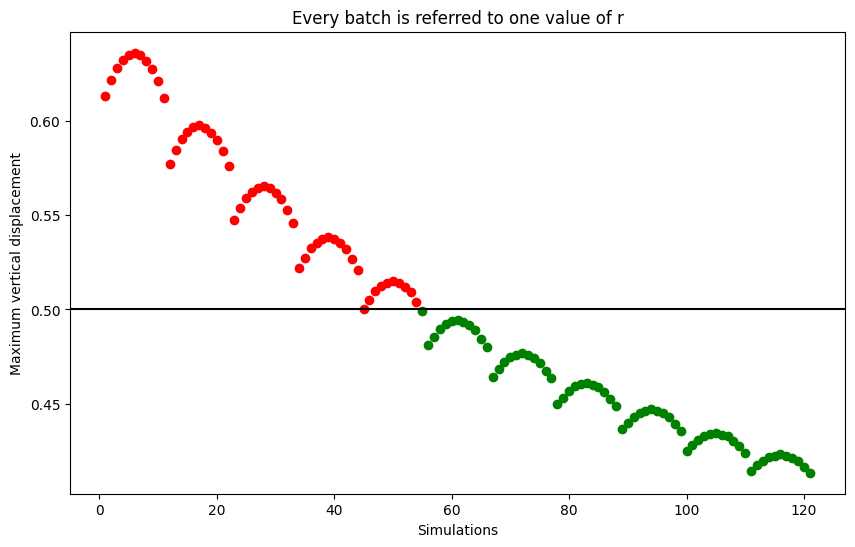

In [ ]:
# Plot the solutions groupped by a single value of r
plt.figure(figsize = (10, 6))
plt.scatter(sim_vect[mask_up], max_disp[mask_up], color='red')
plt.scatter(sim_vect[mask_down], max_disp[mask_down], color='green')
plt.axhline(y = 0.5, color = 'k')
plt.xlabel('Simulations')
plt.ylabel('Maximum vertical displacement')
plt.title('Every batch is referred to one value of r')
clc()

In [ ]:
rr = np.repeat(r_vect, n_t)
tt = np.tile(theta_vect, n_r)

# Reshape to obtain a matrix where each row contains all the angles for one value of r:
max_disp_new = max_disp.reshape(n_r, n_t)
mask_up_new = mask_up.reshape(n_r, n_t)
mask_down_new = mask_down.reshape(n_r, n_t)
rr_new = rr.reshape(n_r, n_t)
tt_new = tt.reshape(n_r, n_t)

# Transposition to obtain that each row contains all the r values for one value of theta:
max_disp_new = max_disp_new.T
mask_up_new = mask_up_new.T
mask_down_new = mask_down_new.T
rr_new = rr_new.T
tt_new = tt_new.T

# Reshape to re-obtain a vector:
max_disp = max_disp_new.reshape(total_comb)
mask_up = mask_up_new.reshape(total_comb)
mask_down = mask_down_new.reshape(total_comb)
rr = rr_new.reshape(total_comb)
tt = tt_new.reshape(total_comb)

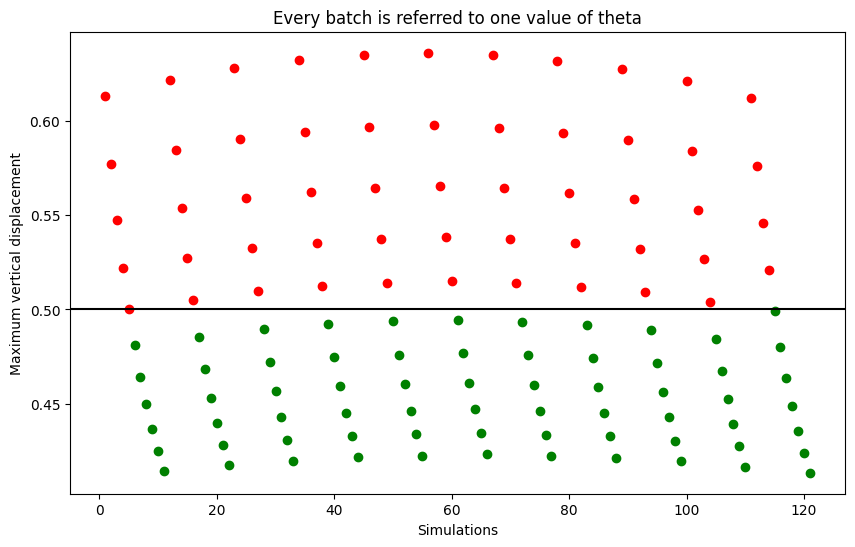

In [ ]:
# Plot the solutions groupped by a single value of theta
plt.figure(figsize = (10, 6))
plt.scatter(sim_vect[mask_up], max_disp[mask_up], color='red')
plt.scatter(sim_vect[mask_down], max_disp[mask_down], color='green')
plt.axhline(y = 0.5, color = 'k')
plt.xlabel('Simulations')
plt.ylabel('Maximum vertical displacement')
plt.title('Every batch is referred to one value of theta')
clc()

In [ ]:
# Find the minum value of r that guarantees that the displacement is lower than the threshold
r_min = np.zeros(n_t)

for i in range(n_t):
  for j in range(n_r-1):
    if mask_up_new[i, j] == True and mask_up_new[i, j+1] == False:
      r_min[i] = rr_new[i, j]

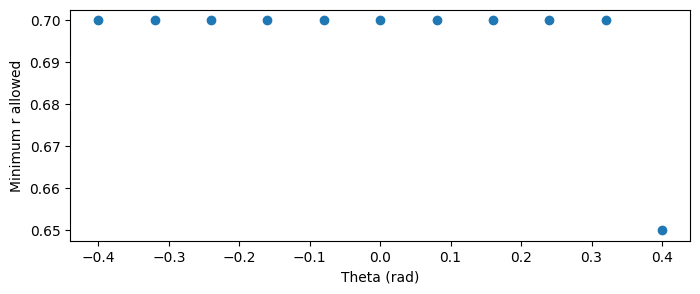

In [ ]:
# Plot the trend
plt.figure(figsize = (8, 3))
plt.scatter(theta_vect, r_min)
plt.xlabel('Theta (rad)')
plt.ylabel('Minimum r allowed')
clc()